# 03 - Distortions (Part 2: introduce distortions, measure degradation)

Applies the 3 distortions (salt & pepper noise, motion blur, JPEG
compression) at every configured intensity level, re-runs all 4 tasks.


In [1]:
import os
import sys

IN_COLAB = "google.colab" in str(get_ipython())
REPO_URL = "https://github.com/Shir-Siman-Tov/Image-Processing-Project.git"
REPO_DIR = "/content/Image-Processing-Project"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.exists(REPO_DIR):
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")
    else:
        # Runtime already had this repo cloned from an earlier cell run in this
        # session - pull so we don't keep running against a stale checkout.
        get_ipython().system(f"git -C {REPO_DIR} pull")
    os.chdir(REPO_DIR)
    get_ipython().system("pip install -q -e .")
    get_ipython().system("pip install -q -r requirements.txt")

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 8 (delta 5), reused 8 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 1.38 KiB | 353.00 KiB/s, done.
From https://github.com/Shir-Siman-Tov/Image-Processing-Project
   0fec59d..88e7cea  main       -> origin/main
Updating 0fec59d..88e7cea
Fast-forward
 notebooks/03_distortions.ipynb |  6 +++---
 src/ipproj/viz/plotting.py     | 35 +++++++++++++++++++++++++----------
 2 files changed, 28 insertions(+), 13 deletions(-)
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ipproj (pyproject.toml) ... done


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from ultralytics import YOLO

from ipproj import config
from ipproj.datasets import kitti, kitti_flow
from ipproj.datasets.kitti import read_image
from ipproj.datasets.kitti_flow import read_kitti_flow_png
from ipproj.datasets.materialize import materialize_transformed
from ipproj.tasks import feature_matching, optical_flow, object_detection, semantic_segmentation
from ipproj.distortions import REGISTRY as DISTORTIONS
from ipproj.metrics.snr import compute_snr_db
from ipproj.metrics.detection_map import per_class_ap_dict
from ipproj.viz.plotting import (
    plot_before_after, plot_grouped_bar_per_class, plot_image_grid, plot_metric_bars_by_condition,
    plot_metric_vs_intensity, plot_metric_vs_snr_by_distortion, save_figure,
)
from ipproj.reporting import save_results_csv

detection_splits = kitti.load_object_detection_subset()
segmentation_splits = kitti.load_semantic_segmentation_subset()
flow_splits = kitti_flow.load_optical_flow_subset()

checkpoint_path = (config.CHECKPOINT_ROOT / "yolo_clean_baseline_path.txt").read_text().strip()
yolo_model = YOLO(checkpoint_path)
segformer_model, segformer_processor = semantic_segmentation.load_pretrained()

clean_baseline = pd.read_csv(config.RESULTS_ROOT / "02_clean_baseline.csv").set_index(["task", "metric"])["value"]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

## Before/after visualization per distortion (strongest intensity)

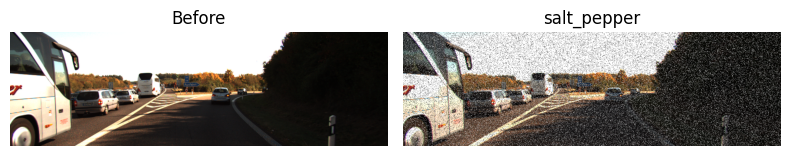

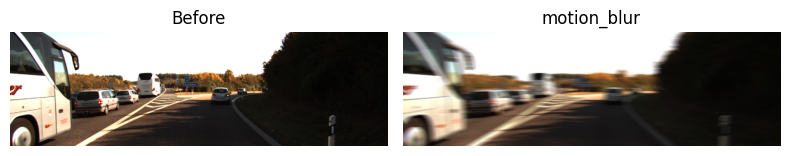

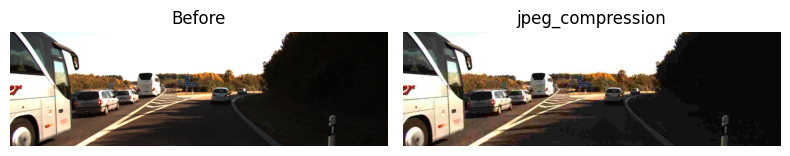

In [4]:
sample_image = read_image(detection_splits["test"][0].image_path)
for name, module in DISTORTIONS.items():
    distorted = module.distort(sample_image, level=len(module.LEVELS) - 1)
    fig = plot_before_after(sample_image, distorted, title_after=f"{name}")
    save_figure(fig, f"03_distortions/before_after_{name}.png")

## Distortion severity grid (all distortions x all levels)

One figure showing every distortion (row) at every configured severity level
(column) applied to the same sample image.


PosixPath('/content/Image-Processing-Project/figures/03_distortions/all_distortions_all_levels_grid.png')

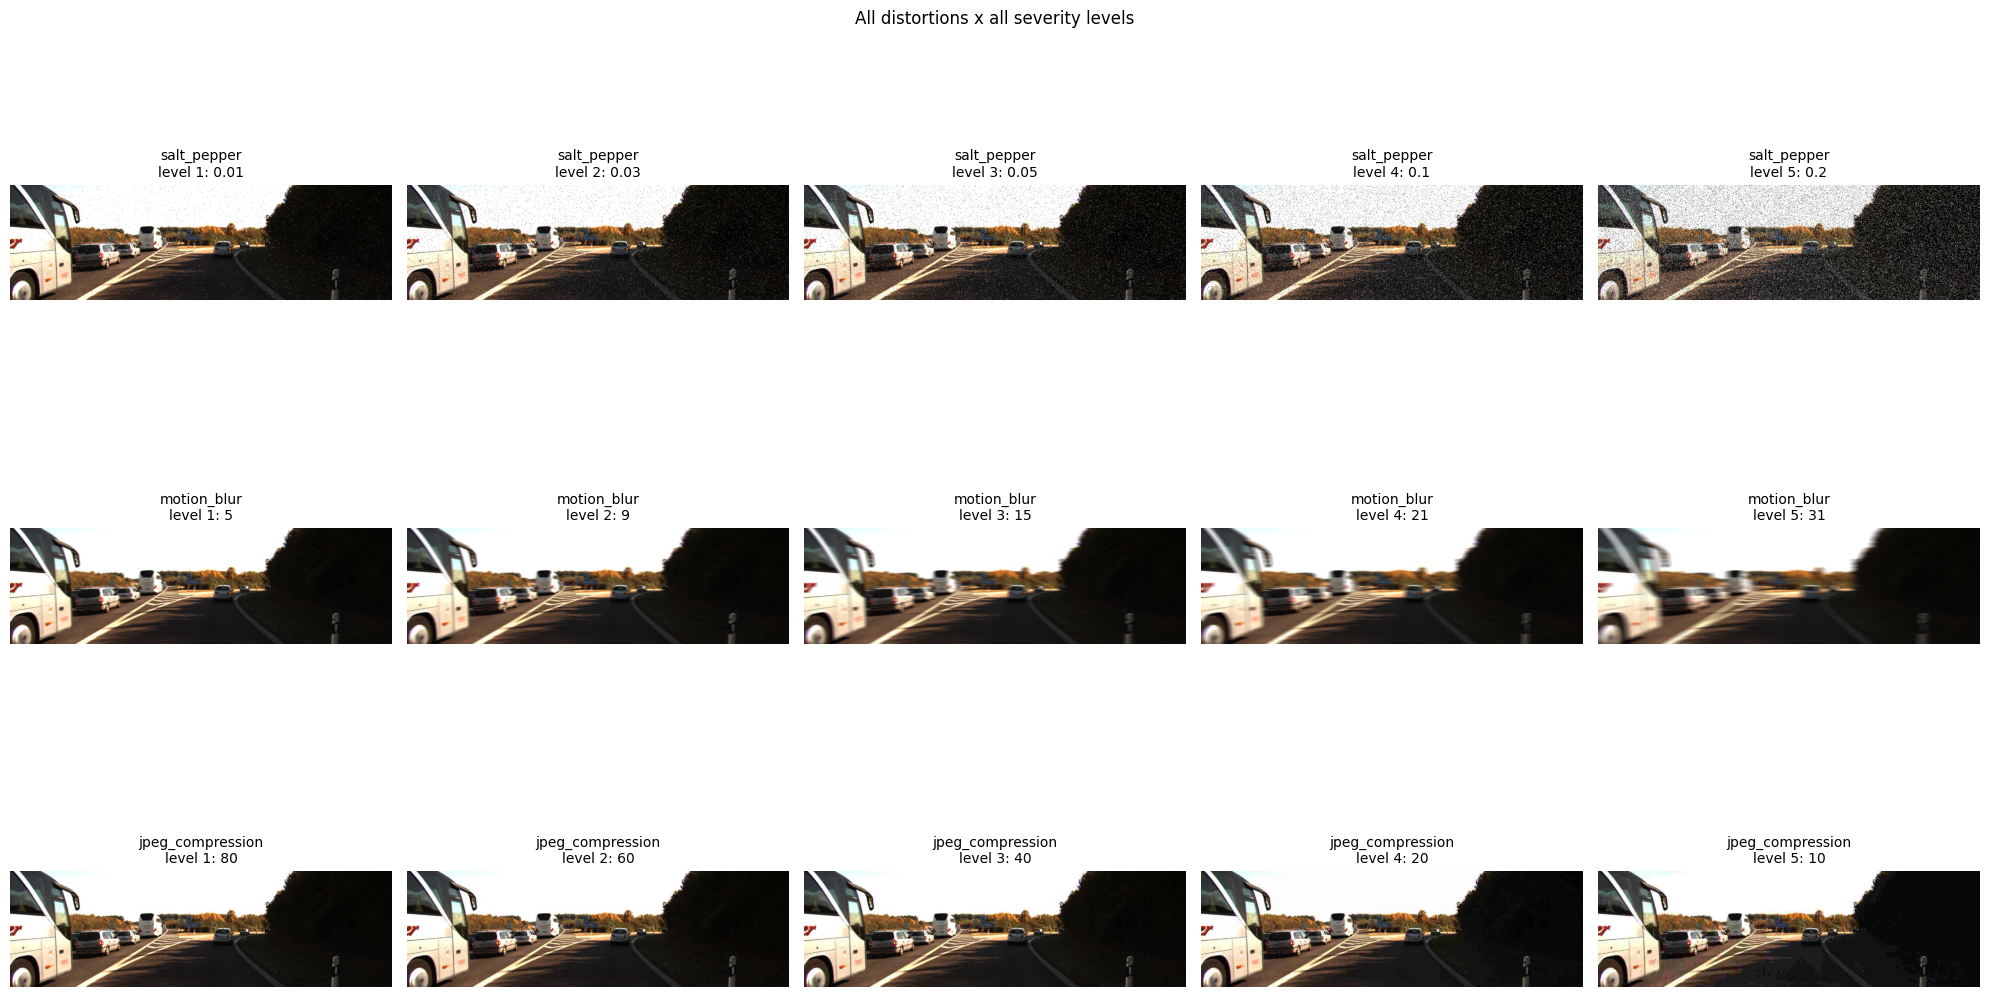

In [5]:
grid_images = []
grid_titles = []
for name, module in DISTORTIONS.items():
    for level in range(len(module.LEVELS)):
        grid_images.append(module.distort(sample_image, level))
        grid_titles.append(f"{name}\nlevel {level + 1}: {module.LEVELS[level]}")

n_levels = len(next(iter(DISTORTIONS.values())).LEVELS)
fig = plot_image_grid(grid_images, titles=grid_titles, ncols=n_levels)
fig.suptitle("All distortions x all severity levels")
save_figure(fig, "03_distortions/all_distortions_all_levels_grid.png")

Above we can see the different degrees of severity for each distortion.


**1. Salt-and-Pepper Noise:** Isolated, stark white and black pixels randomly scattered across the image. Corrupts a fraction of random pixels by overwriting their true intensity values. high-frequency spatial noise.


**2. Motion Blur:** Directional streaking, trailing, or smearing across the image. Effectively stripping away high spatial frequencies (sharp transitions, fine lines, and micro-textures).


**3. JPEG Compression:** High quality compression (70 -100) seems the same as the clean image to the human eye. Low Quality (1–30) makes halo-like "ringing" around sharp edges, and reduced color saturation.


## Per-class breakdown: clean vs. a severe distortion

Detection mAP and segmentation IoU per class, clean vs. the most severe
level of one representative distortion (motion blur, level 5/5), to see
which classes break first under a harsh condition rather than only looking
at aggregate metrics.

PosixPath('/content/Image-Processing-Project/figures/03_distortions/segmentation_iou_per_class_clean_vs_motion_blur_severe.png')

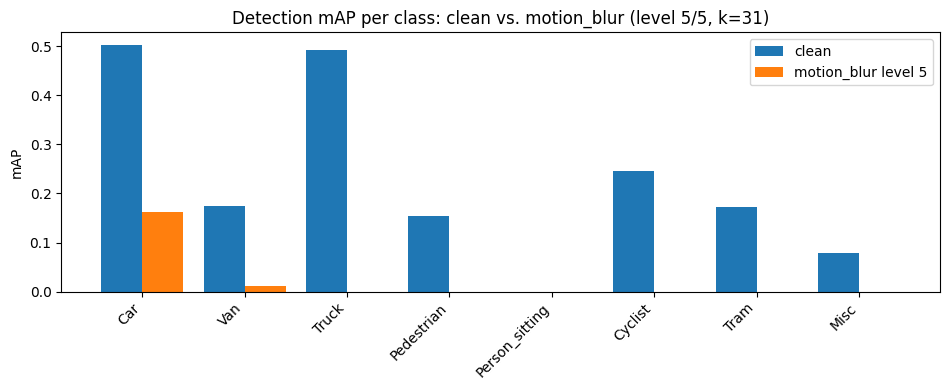

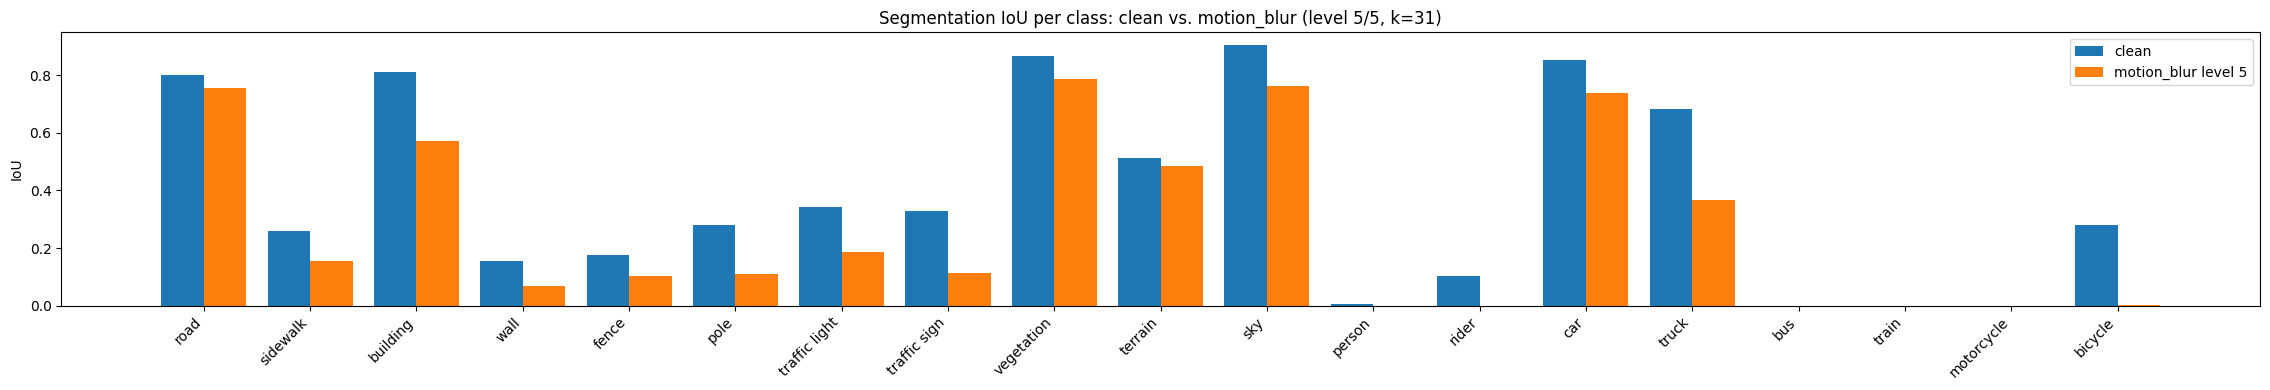

In [6]:
SEVERE_DISTORTION = "motion_blur"
SEVERE_LEVEL = len(DISTORTIONS[SEVERE_DISTORTION].LEVELS) - 1
severe_module = DISTORTIONS[SEVERE_DISTORTION]
severe_distort_fn = lambda img, m=severe_module, l=SEVERE_LEVEL: m.distort(img, l)
severe_out_dir = config.DISTORTED_ROOT / SEVERE_DISTORTION / f"level_{SEVERE_LEVEL}"
severe_label = f"{SEVERE_DISTORTION} level {SEVERE_LEVEL + 1}"

# 02_clean_baseline.csv only stores aggregate scalars, so the clean per-class
# breakdown is recomputed here to pair against the severe-distortion one.
clean_detection_metrics = object_detection.evaluate(yolo_model, detection_splits["test"])
clean_segmentation_iou = semantic_segmentation.evaluate(segformer_model, segformer_processor, segmentation_splits["test"])

severe_detection = materialize_transformed(detection_splits["test"], severe_distort_fn, severe_out_dir / "detection")
severe_detection_metrics = object_detection.evaluate(yolo_model, severe_detection)

severe_segmentation = materialize_transformed(segmentation_splits["test"], severe_distort_fn, severe_out_dir / "segmentation")
severe_segmentation_iou = semantic_segmentation.evaluate(segformer_model, segformer_processor, severe_segmentation)

# per_class_ap_dict() aligns by class name rather than assuming identical
# order/coverage between the clean and severe evaluate() calls, and drops
# any class left undefined (no valid ground truth in that call) rather than
# surfacing torchmetrics/pycocotools' -1 sentinel.
clean_detection_by_class = per_class_ap_dict(clean_detection_metrics)
severe_detection_by_class = per_class_ap_dict(severe_detection_metrics)

detection_series = {
    "clean": [clean_detection_by_class.get(c, 0.0) for c in config.KITTI_DETECTION_CLASSES],
    severe_label: [severe_detection_by_class.get(c, 0.0) for c in config.KITTI_DETECTION_CLASSES],
}
fig = plot_grouped_bar_per_class(
    config.KITTI_DETECTION_CLASSES, detection_series, ylabel="mAP",
    title=f"Detection mAP per class: clean vs. {SEVERE_DISTORTION} "
          f"(level {SEVERE_LEVEL + 1}/{len(severe_module.LEVELS)}, k={severe_module.LEVELS[SEVERE_LEVEL]})",
)
save_figure(fig, "03_distortions/detection_map_per_class_clean_vs_motion_blur_severe.png")

segmentation_series = {
    "clean": clean_segmentation_iou.tolist(),
    severe_label: severe_segmentation_iou.tolist(),
}
fig = plot_grouped_bar_per_class(
    config.CITYSCAPES_TRAINID_LABELS, segmentation_series, ylabel="IoU",
    title=f"Segmentation IoU per class: clean vs. {SEVERE_DISTORTION} "
          f"(level {SEVERE_LEVEL + 1}/{len(severe_module.LEVELS)}, k={severe_module.LEVELS[SEVERE_LEVEL]})",
)
save_figure(fig, "03_distortions/segmentation_iou_per_class_clean_vs_motion_blur_severe.png")

**Object Detection mAP per class:** 6 out of the 8 evaluation classes drop straight to 0.0 mAP (or near zero) under severe motion blur. YOLO relies heavily on sharp spatial boundaries and high-frequency edge gradients to propose bounding box anchors. Morion blur smears object boundaries into the backgroundcausing the detector to miss candidate region proposals.

**Semantic Segmentation IoU per class:** Large spatial regions retain substantial performance under heavy blur.SegFormer uses hierarchical vision transformers that leverage global context rather than strictly depending on sharp local edges.


## Degradation sweep

For each distortion x intensity level: distort the test split, re-run all 4
tasks, and record metrics + a representative SNR value.


In [8]:
results = []

for name, module in DISTORTIONS.items():
    for level in range(len(module.LEVELS)):
        distort_fn = lambda img, m=module, l=level: m.distort(img, l)
        out_dir = config.DISTORTED_ROOT / name / f"level_{level}"

        distorted_detection = materialize_transformed(detection_splits["test"], distort_fn, out_dir / "detection")
        detection_metrics = object_detection.evaluate(yolo_model, distorted_detection)

        distorted_segmentation = materialize_transformed(segmentation_splits["test"], distort_fn, out_dir / "segmentation")
        segmentation_metrics = semantic_segmentation.evaluate(segformer_model, segformer_processor, distorted_segmentation)

        match_accuracies = []
        good_match_ratios = []
        orb_snr_values = []
        for sample in detection_splits["test"][:20]:
            clean = read_image(sample.image_path)
            distorted = module.distort(clean, level)
            _, _, _, accuracy, good_match_ratio = feature_matching.match(clean, distorted)
            match_accuracies.append(accuracy)
            good_match_ratios.append(good_match_ratio)
            orb_snr_values.append(compute_snr_db(clean, distorted))

        epe_values = []
        fl_error_values = []
        flow_snr_values = []
        for sample in flow_splits["test"]:
            frame1 = read_image(sample.frame1_path)
            frame2 = read_image(sample.frame2_path)
            distorted_frame2 = module.distort(frame2, level)
            gt_flow, valid = read_kitti_flow_png(sample.flow_gt_path)
            flow_metrics = optical_flow.evaluate(frame1, distorted_frame2, gt_flow, valid)
            epe_values.append(flow_metrics["epe"])
            fl_error_values.append(flow_metrics["fl_error"])
            flow_snr_values.append(compute_snr_db(frame2, distorted_frame2))

        detection_snr_values = []
        for sample in detection_splits["test"]:
            clean = read_image(sample.image_path)
            detection_snr_values.append(compute_snr_db(clean, module.distort(clean, level)))

        segmentation_snr_values = []
        for sample in segmentation_splits["test"]:
            clean = read_image(sample.image_path)
            segmentation_snr_values.append(compute_snr_db(clean, module.distort(clean, level)))

        results.append({
            "distortion": name,
            "level": level,
            "orb_snr_db": float(np.mean(orb_snr_values)),
            "flow_snr_db": float(np.mean(flow_snr_values)),
            "detection_snr_db": float(np.mean(detection_snr_values)),
            "segmentation_snr_db": float(np.mean(segmentation_snr_values)),
            "match_accuracy": float(np.mean(match_accuracies)),
            "good_match_ratio": float(np.mean(good_match_ratios)),
            "epe": float(np.mean(epe_values)),
            "fl_error": float(np.mean(fl_error_values)),
            "map": float(detection_metrics["map"]),
            "map_50": float(detection_metrics["map_50"]),
            "map_75": float(detection_metrics["map_75"]),
            "mar_100": float(detection_metrics["mar_100"]),
            "mean_iou": float(segmentation_metrics.mean()),
        })

distortion_results = pd.DataFrame(results)
config.RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
distortion_results.to_csv(config.RESULTS_ROOT / "03_distortions.csv", index=False)
save_results_csv(distortion_results, "03_distortions/summary.csv")
distortion_results

,distortion,level,orb_snr_db,flow_snr_db,detection_snr_db,segmentation_snr_db,match_accuracy,good_match_ratio,epe,fl_error,map,map_50,map_75,mar_100,mean_iou
0,salt_pepper,0,18.103473,18.103886,18.101000,18.063212,0.986814,0.62435,27.535070,0.531714,0.205872,0.352426,0.221588,0.249715,0.366901
1,salt_pepper,1,13.371464,13.377802,13.383442,13.345481,0.972056,0.49680,27.177678,0.526431,0.136045,0.255470,0.160007,0.158813,0.284052
2,salt_pepper,2,11.175121,11.180128,11.177519,11.143397,0.964735,0.43940,27.236815,0.532471,0.067536,0.122544,0.064096,0.077581,0.264800
3,salt_pepper,3,8.150841,8.156663,8.156894,8.119757,0.942779,0.35110,27.465162,0.550699,0.030197,0.055514,0.026572,0.032466,0.206156
4,salt_pepper,4,5.120299,5.131436,5.123631,5.093667,0.889105,0.24240,28.226103,0.578206,0.006153,0.009901,0.008487,0.004906,0.120734
5,motion_blur,0,21.435641,21.316038,21.134155,21.319398,0.983330,0.70130,28.815978,0.566246,0.249439,0.380582,0.266364,0.291867,0.387036
6,motion_blur,1,18.410742,18.386397,18.136417,18.388241,0.934246,0.42895,28.946348,0.581102,0.140816,0.218986,0.174203,0.164794,0.366650
7,motion_blur,2,16.328291,16.395154,16.092038,16.384471,0.696171,0.20610,29.036451,0.616235,0.094616,0.158569,0.090566,0.105684,0.340375
8,motion_blur,3,15.179932,15.273737,14.954698,15.249523,0.514160,0.11010,29.016077,0.647307,0.056286,0.096459,0.045100,0.065298,0.313366
9,motion_blur,4,14.004426,14.085728,13.778510,14.055593,0.322907,0.05105,29.035952,0.700774,0.024922,0.045955,0.024911,0.030402,0.273946


## Performance vs. SNR

PosixPath('/content/Image-Processing-Project/figures/03_distortions/performance_vs_snr_grid.png')

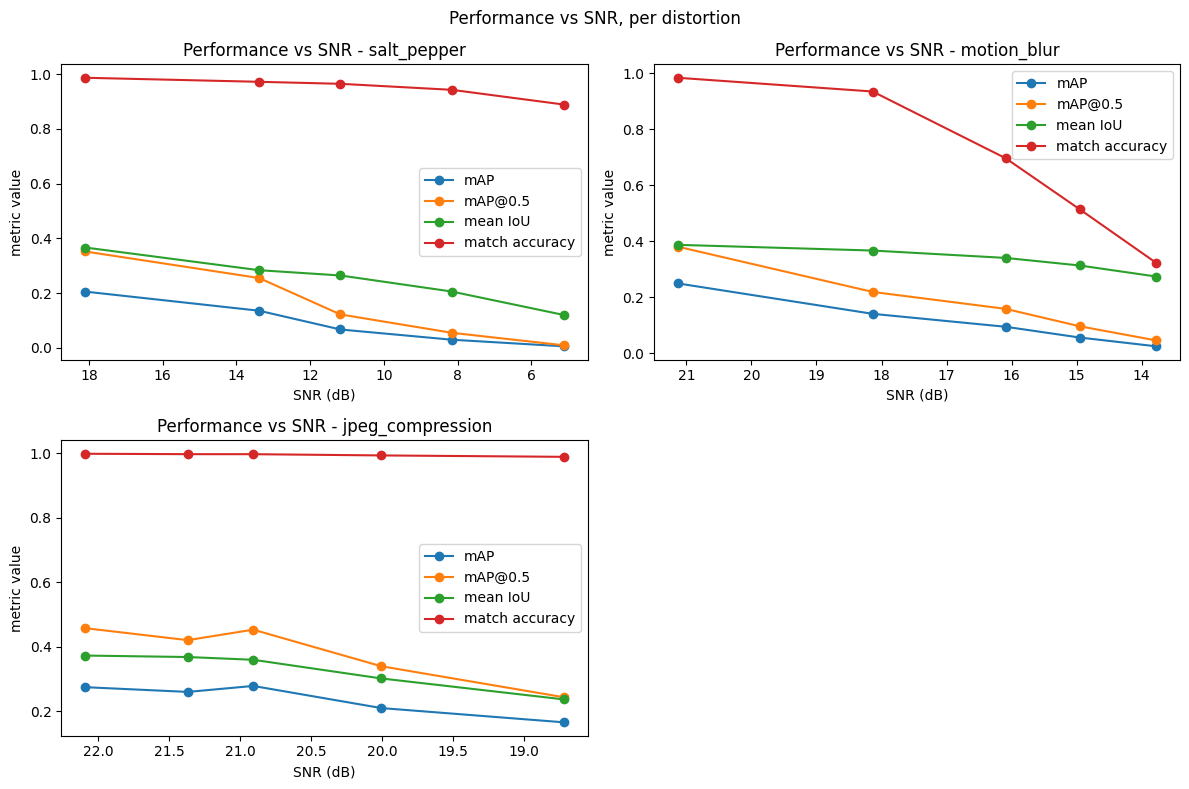

In [9]:
ncols = 2
nrows = (len(DISTORTIONS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))

for name, ax in zip(DISTORTIONS, axes.flat):
    subset = distortion_results[distortion_results["distortion"] == name].sort_values("detection_snr_db")
    plot_metric_vs_intensity(
        subset["detection_snr_db"].tolist(),
        {
            "mAP": subset["map"].tolist(),
            "mAP@0.5": subset["map_50"].tolist(),
            "mean IoU": subset["mean_iou"].tolist(),
            "match accuracy": subset["match_accuracy"].tolist(),
        },
        xlabel="SNR (dB)", ylabel="metric value", title=f"Performance vs SNR - {name}",
        invert_xaxis=True, ax=ax,
    )

for ax in axes.flat[len(DISTORTIONS):]:
    ax.axis("off")

fig.suptitle("Performance vs SNR, per distortion")
fig.tight_layout()
save_figure(fig, "03_distortions/performance_vs_snr_grid.png")

The graphs above illustrate how three different Computer Vision tasks—Object Detection (mAP, mAP\@0.5), Semantic Segmentation (mean IoU), and Feature Matching (match accuracy)—degrade as image distortion increases.




*   **Salt & Pepper Noise:** Feature Matching (Red Line): Highly resilient. ORB can still match keypoint descriptors between valid uncorrupted patches.
Semantic Segmentation (Green Line) Degrades gradually , High-density impulse noise breaks smooth texture patterns, but global visual context helps SegFormer retain partial class segmentations. Object Detection Suffers a severe collapse , Random high-contrast black/white pixels destroy local gradient information, preventing YOLO from forming confident bounding box proposals.




*  **Motion Blur:** Feature Matching Plummets dramatically , Motion blur smooths out sharp corners and fine intensity transitions.ORB descriptor representations become distorted and fail to match. Semantic Segmentation -
resilient. It stays nearly flat. Object Detection - Drops continuously toward zero.


*  **JPEG Compression:** Feature Matching- Remains essentially the same.
Segmentation & Detection - Experience a moderate decline.




## Performance vs. mean SNR, per task (with clean-baseline reference)

One figure per task metric: a curve per distortion type (own mean SNR per
level, averaged over that task's own sample images) plus a horizontal
reference line at the clean (undistorted) baseline value from
`02_clean_baseline.csv`. ORB's reference line is a clean-vs-clean self-match
accuracy (a trivial/ceiling case, not a clean-vs-distorted comparison like
the other tasks' baselines) - see `02_clean_baseline.ipynb`.

PosixPath('/content/Image-Processing-Project/figures/03_distortions/performance_vs_mean_snr_grid.png')

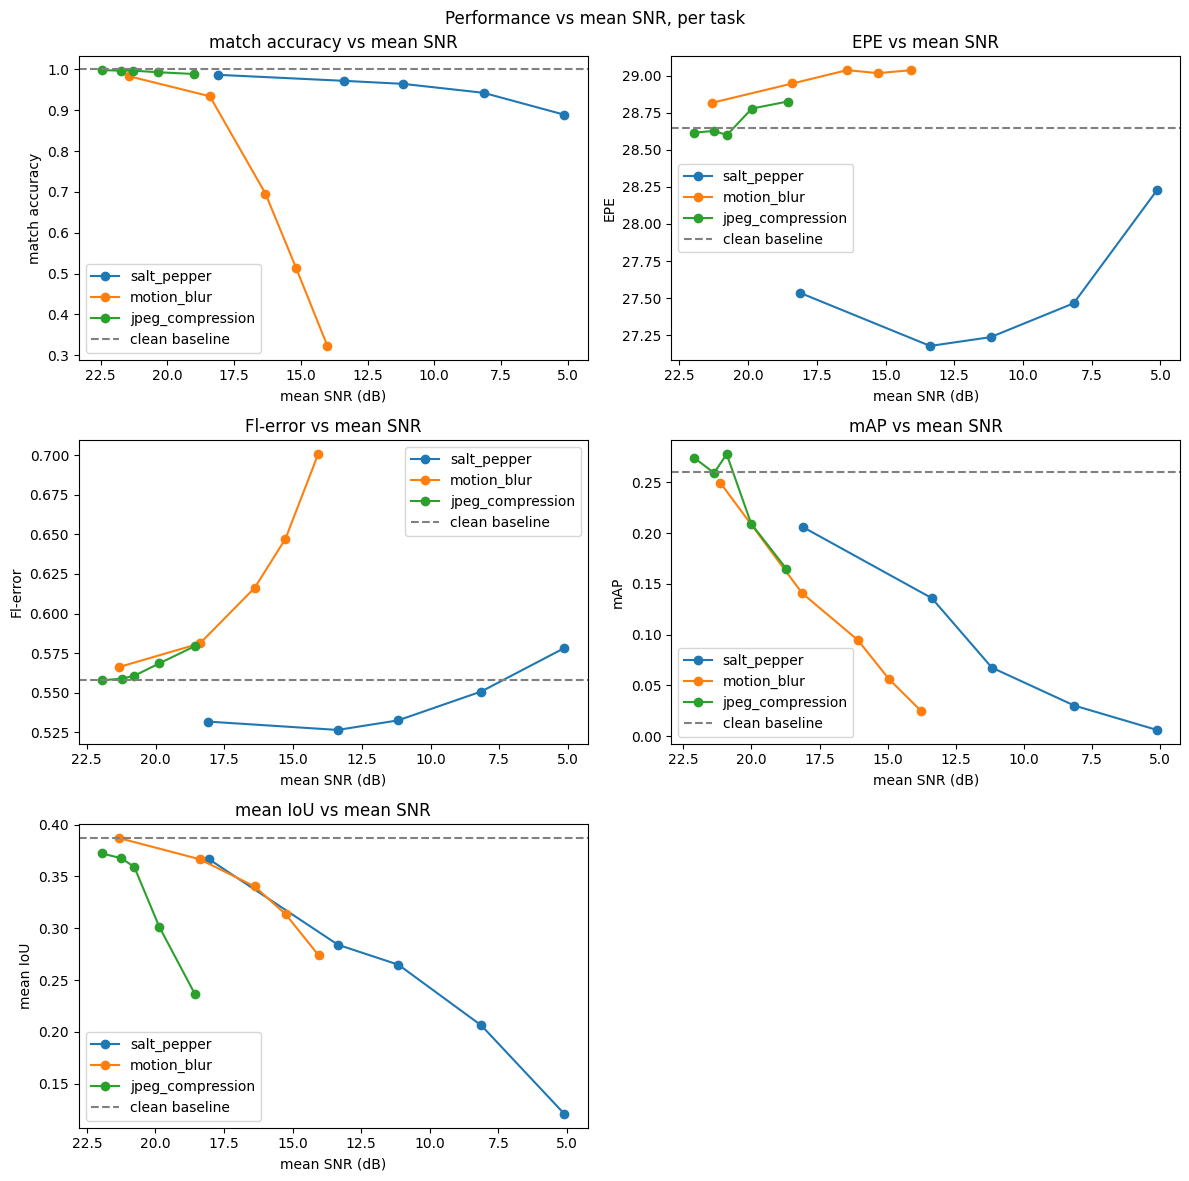

In [10]:
metric_plots = [
    ("match_accuracy", "orb_snr_db", "match accuracy", ("feature_matching", "match_accuracy")),
    ("epe", "flow_snr_db", "EPE", ("optical_flow", "epe")),
    ("fl_error", "flow_snr_db", "Fl-error", ("optical_flow", "fl_error")),
    ("map", "detection_snr_db", "mAP", ("object_detection", "map")),
    ("mean_iou", "segmentation_snr_db", "mean IoU", ("semantic_segmentation", "mean_iou")),
]

ncols = 2
nrows = (len(metric_plots) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))

for (metric_col, snr_col, ylabel, baseline_key), ax in zip(metric_plots, axes.flat):
    snr_by_distortion = {}
    metric_by_distortion = {}
    for name in DISTORTIONS:
        subset = distortion_results[distortion_results["distortion"] == name]
        snr_by_distortion[name] = subset[snr_col].tolist()
        metric_by_distortion[name] = subset[metric_col].tolist()

    clean_reference = float(clean_baseline.loc[baseline_key]) if baseline_key is not None else None

    plot_metric_vs_snr_by_distortion(
        snr_by_distortion, metric_by_distortion, clean_reference,
        xlabel="mean SNR (dB)", ylabel=ylabel, title=f"{ylabel} vs mean SNR",
        invert_xaxis=True, ax=ax,
    )

for ax in axes.flat[len(metric_plots):]:
    ax.axis("off")

fig.suptitle("Performance vs mean SNR, per task")
fig.tight_layout()
save_figure(fig, "03_distortions/performance_vs_mean_snr_grid.png")

**match accuracy vs mean SNR:** Motion blur - Accuracy drops rapidly. Salt & Pepper - resilient , ORB can still successfully extract and match descriptors from uncorrupted pixel neighborhoods. JPEG Compression - Displays almost no performance loss.

**EPE & Fl-error vs mean SNR:** Lower is better for both EPE and Fl-error. Motion Blur - Causes severe flow estimation degradation , both EPE and Fl rise.
JPEG Compression - Slightly increases EPE and Fl-error above baseline. Salt & Pepper - At mild-to-moderate noise levels ($18$dB- $13$dB), salt-and-pepper noise produces lower EPE and Fl-error than the clean baseline, before increasing at 5dB.
Reason: Impulse noise creates identical, stationary $0$ or $255$ pixel spikes across consecutive frames. Deep optical
 flow networks often infer near-zero motion for these static noise points.

**mAP vs mean SNR:** All three distortion types cause continuous performance drops.
JPEG Compression - Exhibits the steepest drop per dB of SNR loss. Motion Blur & Salt & Pepper - xhibit steady, linear declines down toward $0$ mAP as object boundary silhouettes degrade.

**mean IoU vs mean SNR:** JPEG Compression - Shows extreme sensitivity relative to SNR change.
Motion Blue & Salt & Pepper - Show gradual degradation

---

| Vision Task | Most Damaging Distortion | Most Tolerated Distortion | Key Bottleneck |
| --- | --- | --- | --- |
| **Feature Matching** | Motion Blur | Salt & Pepper / JPEG | Requires sharp corner points and local high-frequency gradients. |
| **Optical Flow** | Motion Blur | JPEG Compression | Degrades severely when pixel texture correspondence trajectories are smeared. |
| **Object Detection** | JPEG Compression (per dB) / Blur | Salt & Pepper | Requires precise local edge boundary cues to anchor bounding boxes. |
| **Semantic Segmentation** | JPEG Compression (per dB) | Motion Blur | Uses global spatial context to withstand boundary blur, but drops under heavy quantization. |

## Robustness bar charts (metric vs. distortion severity)

One bar chart per task: a bar per condition ("clean" + every distortion x
severity level, 5 levels each), colored by distortion family, with a red
dashed line at the clean baseline from `02_clean_baseline.csv`. Unlike the
SNR-axis plots above, the x-axis here is the actual severity parameter
(noise fraction, blur kernel size, JPEG quality), so severity within a
distortion family is directly readable. Optical flow's EPE is an error
metric (lower is better) - taller bars mean worse performance, opposite of
the other three charts.

In [11]:
CLEAN_BAR_COLOR = "#c3c2b7"
DISTORTION_FAMILY_COLORS = {
    "salt_pepper": "#2a78d6",
    "motion_blur": "#eb6834",
    "jpeg_compression": "#1baf7a",
}
SEVERITY_LABEL_FNS = {
    "salt_pepper": lambda v: f"{v:.0%}",
    "motion_blur": lambda v: f"k={v}",
    "jpeg_compression": lambda v: f"q={v}",
}

condition_labels = ["clean"]
condition_colors = [CLEAN_BAR_COLOR]
for name, module in DISTORTIONS.items():
    for raw_value in module.LEVELS:
        condition_labels.append(f"{name}\n{SEVERITY_LABEL_FNS[name](raw_value)}")
        condition_colors.append(DISTORTION_FAMILY_COLORS[name])

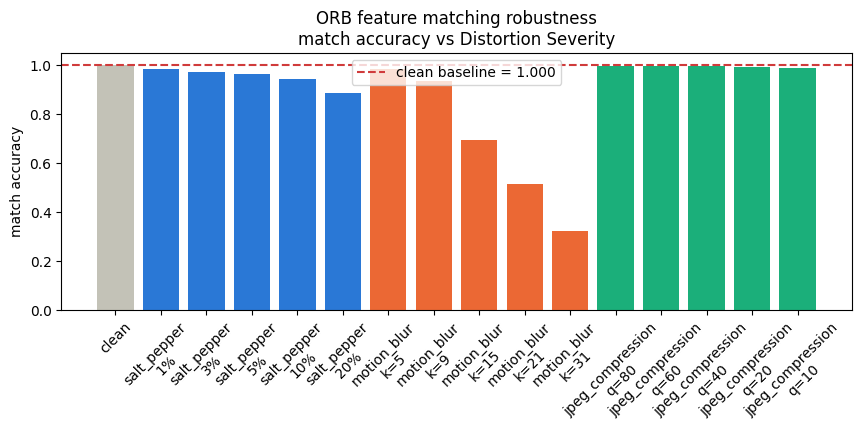

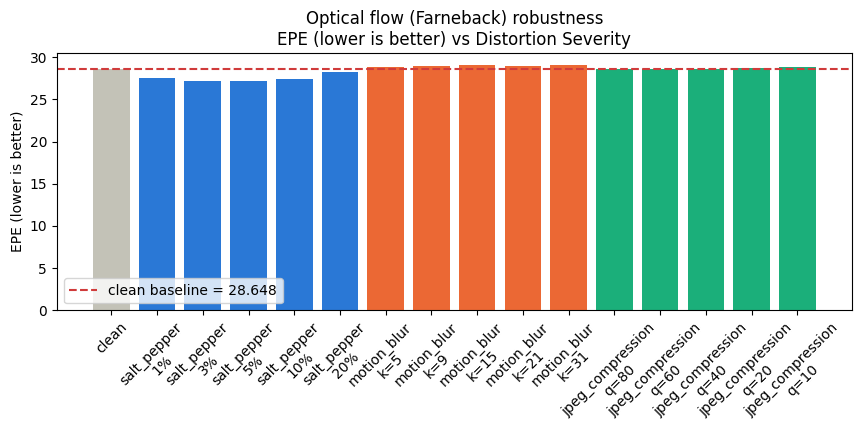

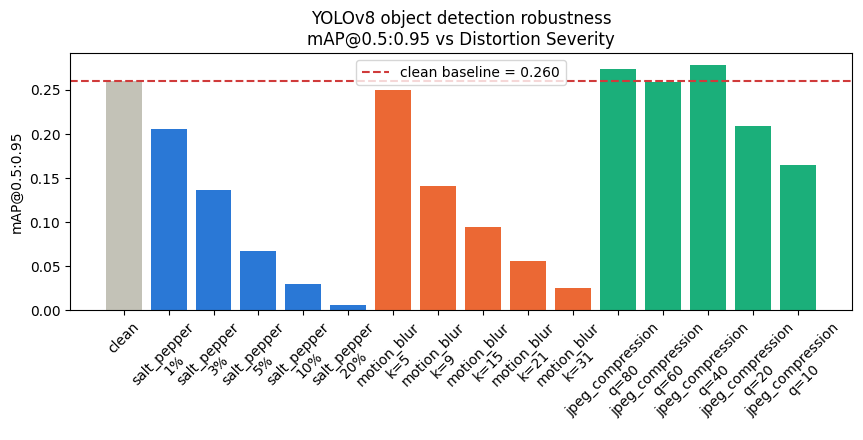

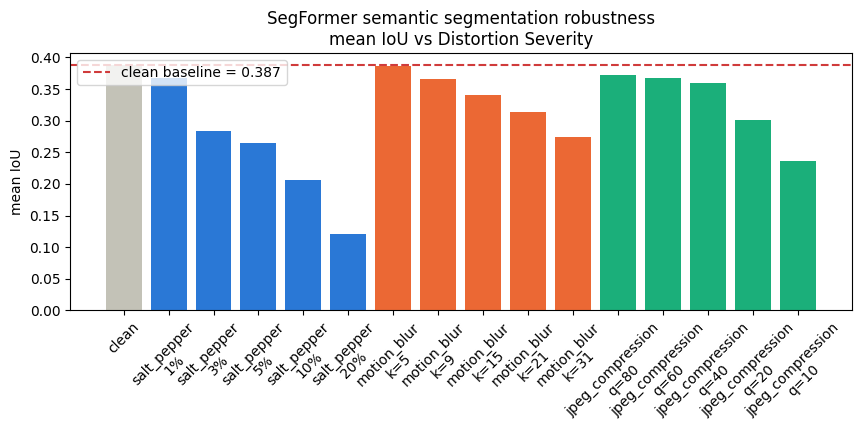

In [12]:
robustness_bar_plots = [
    ("match_accuracy", ("feature_matching", "match_accuracy"), "match accuracy", "ORB feature matching robustness"),
    ("epe", ("optical_flow", "epe"), "EPE (lower is better)", "Optical flow (Farneback) robustness"),
    ("map", ("object_detection", "map"), "mAP@0.5:0.95", "YOLOv8 object detection robustness"),
    ("mean_iou", ("semantic_segmentation", "mean_iou"), "mean IoU", "SegFormer semantic segmentation robustness"),
]

for metric_col, baseline_key, ylabel, title in robustness_bar_plots:
    clean_reference = float(clean_baseline.loc[baseline_key])
    values = [clean_reference]
    for name, module in DISTORTIONS.items():
        for level in range(len(module.LEVELS)):
            row = distortion_results[(distortion_results["distortion"] == name) & (distortion_results["level"] == level)]
            values.append(float(row[metric_col].iloc[0]))

    fig = plot_metric_bars_by_condition(
        condition_labels, values, condition_colors, ylabel=ylabel,
        title=f"{title}\n{ylabel} vs Distortion Severity",
        reference_value=clean_reference, reference_label="clean baseline",
    )
    save_figure(fig, f"03_distortions/{metric_col}_robustness_bars.png")

### Detailed Analysis of Robustness Bar Plots

---

| Task | Primary Vulnerability | Primary Strength | Architectural Insight |
| --- | --- | --- | --- |
| **ORB Feature Matching** | **Motion Blur** ($k \ge 15$) | **JPEG & Salt-Pepper** | Strict dependency on sharp, unblurred high-frequency corners. |
| **Optical Flow** | **Motion Blur** | **JPEG Compression** | Sensitive to texture smearing; impulse noise introduces static artifacts that artificially depress EPE. |
| **YOLOv8 Detection** | **Salt-Pepper & Motion Blur** | **JPEG Compression** ($q \ge 40$) | High sensitivity to local edge/gradient disruptions, causing total proposal collapse under severe noise or blur. |
| **SegFormer Segmentation** | **Salt-Pepper** ($>10\%$) | **Motion Blur & Mild JPEG** | Global context attention mechanisms provide strong structural resilience against spatial blurring. |

## Sync figures/results back to GitHub

`figures/` and `results/` only exist inside this run's throwaway Colab clone
(see the setup cell) - back them up to Drive and push straight to GitHub so
the README's plots/tables actually update. Requires a one-time `GITHUB_TOKEN`
secret in Colab (see this repo's README, "Running on Colab").

In [13]:
from ipproj.colab_sync import sync_outputs_to_drive, git_commit_and_push

if IN_COLAB:
    sync_outputs_to_drive()
    git_commit_and_push("Sync figures/results from notebook 03 (distortions) run")